In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
import seaborn as sns


In [3]:
df=pd.read_csv('Position_Salaries.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Position  10 non-null     object
 1   Level     10 non-null     int64 
 2   Salary    10 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 368.0+ bytes


In [5]:
df=df.drop('Position',axis=1)

In [6]:
X=df.drop('Salary',axis=1)
y=df['Salary']

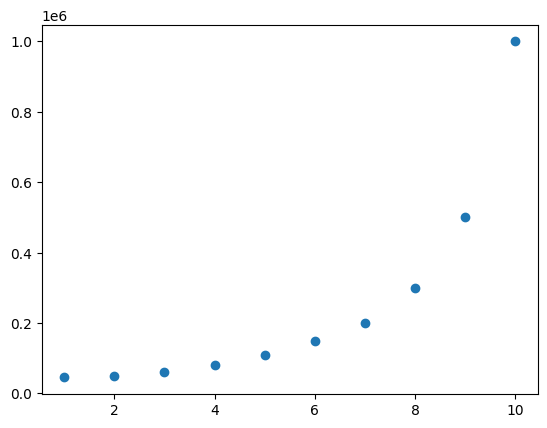

In [7]:
plt.scatter(df['Level'],y)
plt.show()

In [8]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Level   10 non-null     int64
 1   Salary  10 non-null     int64
dtypes: int64(2)
memory usage: 288.0 bytes


In [9]:
df.corr(numeric_only=True)

,Level,Salary
Level,1.000000,0.817949
Salary,0.817949,1.000000


In [10]:
xtrain,xtest,ytrain,ytest=train_test_split(X,y,random_state=42,train_size=0.8)

In [24]:
scalar=StandardScaler()

In [25]:
updated_Xtrain=scalar.fit_transform(xtrain)

In [27]:
updated_Xtest=scalar.transform(xtest)

In [11]:
poly=PolynomialFeatures(degree=2)

In [12]:
updated_Xtrain=poly.fit_transform(xtrain)
updated_Xtest=poly.transform(xtest)


In [13]:
model=LinearRegression()

In [14]:
model.fit(updated_Xtrain,ytrain)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
ytrain_pred=model.predict(updated_Xtrain)

In [16]:
ytest_pred=model.predict(updated_Xtest)

In [17]:
error=ytrain-ytrain_pred

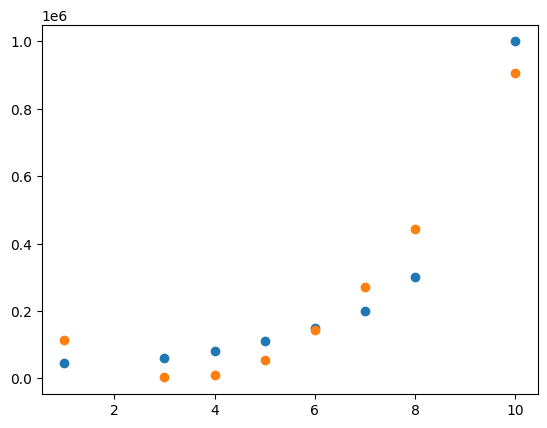

In [18]:
plt.scatter(updated_Xtrain[:,1] ,ytrain)
plt.scatter(updated_Xtrain[:,1] ,ytrain_pred)

### Train score

In [19]:
print("r^2 score: ",r2_score(ytrain,ytrain_pred)) #(actual o/p, predicted o/p)
print("Train MAE:", mean_absolute_error(ytrain, ytrain_pred))
print("Train RMSE:", root_mean_squared_error(ytrain, ytrain_pred))

r^2 score:  0.9280776280497959
Train MAE: 70986.34468626347
Train RMSE: 79541.76929650217


### Test Score


In [20]:
print("r^2 score: ",r2_score(ytest,ytest_pred))
print("Test MAE:", mean_absolute_error(ytest, ytest_pred))
print("Test RMSE:", root_mean_squared_error(ytest, ytest_pred))

r^2 score:  0.7666492889299912
Test MAE: 82607.7586206898
Test RMSE: 108689.37274600125


### conclusion

"The model achieved a training R² of 0.928 and a testing R² of 0.767. Since the training performance is higher than the 

testing performance by about 0.16, the model shows mild overfitting. However, the testing R² is still reasonably high, 

indicating that the model generalizes fairly well and can be considered a good model with some scope for improvement."